# KMeans Algorithm - Customer Segmentation Dataset

In [ ]:
import pandas as pd # Veri işleme ve analiz için pandas kütüphanesini içe aktarır.
import numpy as np # Sayısal işlemler için numpy kütüphanesini içe aktarır.
import matplotlib.pyplot as plt # Veri görselleştirme için matplotlib kütüphanesini içe aktarır.

from sklearn.preprocessing import StandardScaler # Veriyi ölçeklendirmek için sklearn kütüphanesinden StandardScaler sınıfını içe aktarır.
from sklearn.cluster import KMeans # KMeans algoritması için sklearn kütüphanesinden KMeans sınıfını içe aktarır.
from sklearn.metrics import silhouette_score # Silhouette skorunu hesaplamak için sklearn kütüphanesinden silhouette_score fonksiyonunu içe aktarır.
from sklearn.decomposition import PCA # PCA (Principal Component Analysis) için sklearn kütüphanesinden PCA sınıfını içe aktarır.
from mpl_toolkits.mplot3d import Axes3D  # 3D görselleştirme için mpl_toolkits.mplot3d kütüphanesinden Axes3D sınıfını içe aktarır.

In [8]:
df = pd.read_csv(
    filepath_or_buffer='data/Cust_Segmentation.csv'
)

df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


In [11]:
df.drop(
    columns=['Customer Id', 'Address', 'Defaulted'],
    inplace=True
)

df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,6.3
1,47,1,26,100,4.582,8.218,12.8
2,33,2,10,57,6.111,5.802,20.9
3,29,2,4,19,0.681,0.516,6.3
4,47,1,31,253,9.308,8.908,7.2


In [12]:
df.shape

(850, 7)

In [13]:
df.dtypes.to_frame(name='dtype')

,dtype
Age,int64
Edu,int64
Years Employed,int64
Income,int64
Card Debt,float64
Other Debt,float64
DebtIncomeRatio,float64


In [14]:
df.isnull().sum()

Age                0
Edu                0
Years Employed     0
Income             0
Card Debt          0
Other Debt         0
DebtIncomeRatio    0
dtype: int64

In [15]:
df.columns

Index(['Age', 'Edu', 'Years Employed', 'Income', 'Card Debt', 'Other Debt',
       'DebtIncomeRatio'],
      dtype='str')

In [16]:
features = ['Age', 'Edu', 'Years Employed', 'Income', 'Card Debt', 'Other Debt', 'DebtIncomeRatio']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[features])

X_scaled = pd.DataFrame(X_scaled, columns=features)

X_scaled.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio
0,0.742915,0.312122,-0.378790,-0.718459,-0.683811,-0.590489,-0.576525
1,1.489490,-0.766349,2.573721,1.384325,1.414474,1.512962,0.391387
2,-0.252518,0.312122,0.211712,0.268032,2.134141,0.801704,1.597554
3,-0.750235,0.312122,-0.674041,-0.718459,-0.421643,-0.754467,-0.576525
4,1.489490,-0.766349,3.311849,5.356249,3.638900,1.716094,-0.442507


1 || 0.0001
Initialization complete
Iteration 0, inertia 7240.8304726428505.
Iteration 1, inertia 5950.000000000001.
Converged at iteration 1: strict convergence.
1 || 0.0001
Initialization complete
Iteration 0, inertia 5747.630220188783.
Iteration 1, inertia 4753.886841590352.
Iteration 2, inertia 4536.213280967919.
Iteration 3, inertia 4442.990991550379.
Iteration 4, inertia 4397.198070703111.
Iteration 5, inertia 4373.006928431194.
Iteration 6, inertia 4361.195356785195.
Iteration 7, inertia 4355.549662943547.
Iteration 8, inertia 4352.336600803206.
Iteration 9, inertia 4350.105130301789.
Iteration 10, inertia 4348.563608728024.
Iteration 11, inertia 4346.9188574329855.
Iteration 12, inertia 4345.449326001168.
Iteration 13, inertia 4344.708371539533.
Iteration 14, inertia 4344.437321753241.
Iteration 15, inertia 4344.270071321562.
Iteration 16, inertia 4344.13647947055.
Converged at iteration 16: strict convergence.
1 || 0.0001
Initialization complete
Iteration 0, inertia 4590.66033

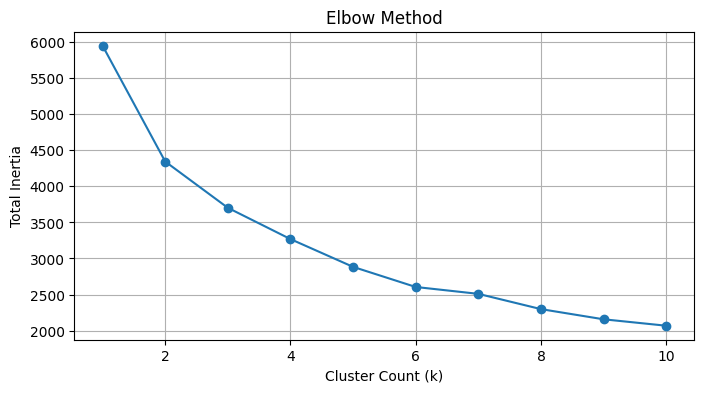

In [17]:
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42,
        verbose=1
    )

    print(f'{km.verbose} || {km.tol}')
    km.fit(X_scaled)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia_values, marker='o')
plt.title('Elbow Method')
plt.xlabel('Cluster Count (k)')
plt.ylabel('Total Inertia')
plt.grid(True)
plt.show()

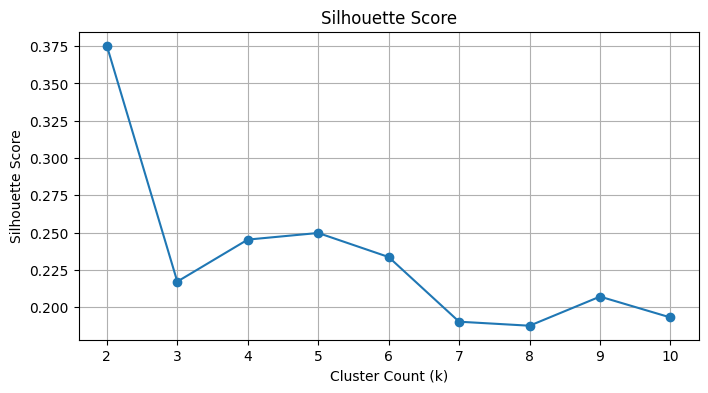

Best k: 2


In [18]:
silhouette_scores = [] # Silhouette Score'ları saklamak için boş bir liste oluşturuyoruz.

for k in range(2, 11): # KMeans algoritması için k değerlerini 2'den 10'a kadar deniyoruz.
    kmeans = KMeans(
        n_clusters=k, # KMeans algoritması için k değerini belirliyoruz.
        init='k-means++', # KMeans algoritması için başlangıç merkezlerini belirliyoruz.
        n_init='auto', # KMeans algoritması için n_init parametresini belirliyoruz.
        random_state=42 # KMeans algoritması için random_state parametresini belirliyoruz.
    ) # KMeans modelini oluşturuyoruz.

    kmeans.fit(X_scaled) # KMeans modelini eğitiyoruz.

    labels = kmeans.labels_ # Her bir veri noktasının hangi kümeye ait olduğunu alıyoruz.

    score = silhouette_score(X_scaled, labels) # Silhouette Score'u hesaplıyoruz.

    silhouette_scores.append(score) # Hesaplanan Silhouette Score'u listeye ekliyoruz.


plt.figure(figsize=(8,4)) # Silhouette Score'ları görselleştirmek için bir grafik oluşturuyoruz.
plt.plot(range(2,11), silhouette_scores, marker='o') # K değerlerine karşılık gelen Silhouette Score'ları çiziyoruz. 
plt.title('Silhouette Score') # Grafiğin başlığını belirliyoruz.
plt.xlabel('Cluster Count (k)') # X eksenini etiketliyoruz.
plt.ylabel('Silhouette Score') # Y eksenini etiketliyoruz.
plt.grid(True) # Grafiğe grid ekliyoruz.
plt.show() # Grafiği gösteriyoruz.


best_k = range(2,11)[silhouette_scores.index(max(silhouette_scores))] # En iyi k değerini buluyoruz.
print("Best k:", best_k)

In [ ]:
silhouette_scores # Silhouette Score'ları yazdırır.

[0.37524350822454117,
 0.2172394086659741,
 0.2453672982285242,
 0.24980591694366872,
 0.23369158902743958,
 0.1903698416141434,
 0.18767586572891834,
 0.20718651585558026,
 0.19320076361829208]

In [20]:
kmeans_final = KMeans(
    n_clusters=4, # En iyi k değeri olan 4'ü kullanarak KMeans modelini oluşturlur.
    init='k-means++', # KMeans algoritması için başlangıç merkezlerini belirler.
    n_init='auto', # KMeans algoritması için n_init parametresini belirler.
    random_state=42 # KMeans algoritması için random_state parametresini belirler.
)

kmeans_final.fit(X_scaled) # KMeans modelini eğitir.

df['Cluster'] = kmeans_final.labels_ # Her bir veri noktasının hangi kümeye ait olduğunu df'e eklenir.

df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio,Cluster
0,41,2,6,19,0.124,1.073,6.3,1
1,47,1,26,100,4.582,8.218,12.8,2
2,33,2,10,57,6.111,5.802,20.9,2
3,29,2,4,19,0.681,0.516,6.3,1
4,47,1,31,253,9.308,8.908,7.2,3


In [21]:
cluster_profile = df.groupby('Cluster').mean().round(2) # Her bir küme için ortalama değerleri hesaplar ve sonuçları 2 ondalık basamağa yuvarlar.

cluster_profile.T # Kümelerin profilini transpoze ederek gösterir.

Cluster,0,1,2,3
Age,41.91,30.21,38.17,47.06
Edu,1.59,1.67,1.96,2.00
Years Employed,14.62,4.44,10.66,22.81
Income,65.12,28.07,58.81,204.25
Card Debt,1.28,0.75,3.41,10.92
Other Debt,2.48,1.60,6.84,15.81
DebtIncomeRatio,6.27,8.68,19.11,16.34


In [24]:
df.groupby('Cluster').count() # Her bir kümede kaç veri noktası olduğunu gösterir.

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio,PCA1,PCA2
Cluster,,,,,,,,,
0,218,218,218,218,218,218,218,218,218
1,456,456,456,456,456,456,456,456,456
2,160,160,160,160,160,160,160,160,160
3,16,16,16,16,16,16,16,16,16


c:\Users\90535\Desktop\SkilledHub\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


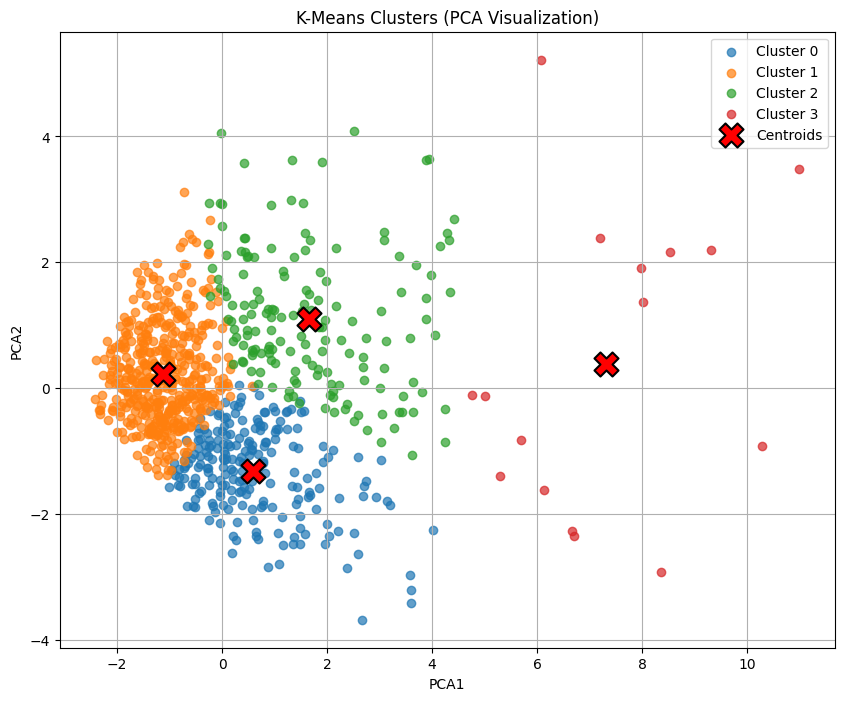

In [28]:
plt.figure(figsize=(10,8)) # PCA ile 2 boyutlu görselleştirme için bir grafik oluşturur.

pca = PCA(n_components=2) # PCA modelini oluşturur ve 2 bileşen kullanır.

pca_result = pca.fit_transform(X_scaled) # PCA modelini eğitir ve veriyi 2 bileşene dönüştürür.

df['PCA1'] = pca_result[:,0] # PCA1 bileşenini df'e ekler.
df['PCA2'] = pca_result[:,1] # PCA2 bileşenini df'e ekler.

centers = kmeans_final.cluster_centers_ # KMeans modelinin öğrenilen küme merkezlerini alır.
centers_pca = pca.transform(centers) # KMeans modelinin öğrenilen küme merkezlerini PCA bileşenlerine dönüştürür.

for c in sorted(df['Cluster'].unique()): # Her bir küme için döngü oluşturur.
    subset = df[df['Cluster'] == c] # Her bir küme için df'den o kümeye ait veri noktalarını içeren bir alt küme oluşturur.

    plt.scatter(
        subset['PCA1'], # PCA1 bileşenini x eksenine, PCA2 bileşenini y eksenine yerleştirir.
        subset['PCA2'], # PCA2 bileşenini y eksenine yerleştirir.
        alpha=0.7, # Noktaların saydamlık seviyesini 0.7 olarak belirler.
        label=f'Cluster {c}' # Her bir kümenin etiketini belirler.
    ) # Her bir küme için PCA1 ve PCA2 bileşenlerine göre noktaları görselleştirir.

plt.scatter(
    centers_pca[:,0], # PCA1 bileşenindeki küme merkezlerini x eksenine yerleştirir.
    centers_pca[:,1], # PCA2 bileşenindeki küme merkezlerini y eksenine yerleştirir.
    s=300, # Küme merkezlerinin boyutunu 300 olarak belirler.
    marker='X', # Küme merkezlerini 'X' işareti ile gösterir.
    c='red', # Küme merkezlerini kırmızı renkle gösterir.
    edgecolors='black', # Küme merkezlerinin kenar renklerini siyah olarak belirler.
    linewidths=1.5, # Küme merkezlerinin kenar kalınlığını 1.5 olarak belirler.
    label='Centroids' # Küme merkezlerinin etiketini 'Centroids' olarak belirler.
) # PCA1 ve PCA2 bileşenlerine göre küme merkezlerini kırmızı 'X' işareti ile görselleştirir.

plt.title('K-Means Clusters (PCA Visualization)') # Grafiğin başlığını belirler.
plt.xlabel('PCA1') # X ekseninin etiketini belirler.
plt.ylabel('PCA2') # Y ekseninin etiketini belirler.
plt.legend() # Legend (açıklama) ekler.
plt.grid() # Grid (ızgara) ekler.

plt.show() # Grafiği gösterir.

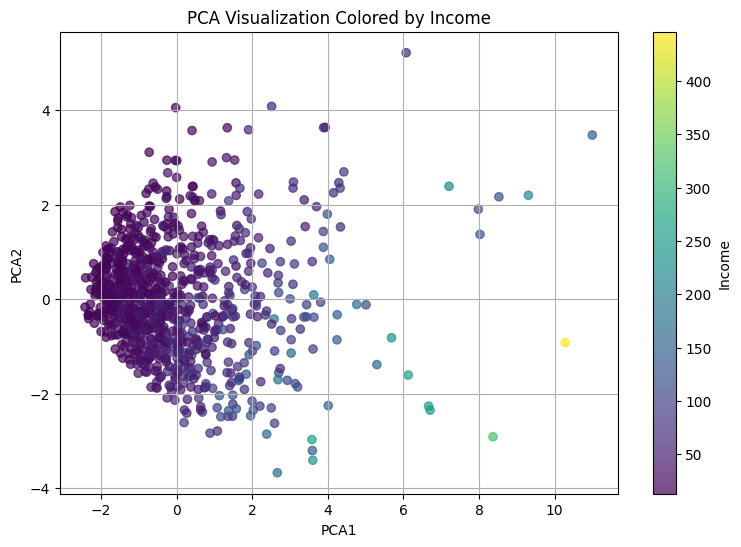

In [ ]:
plt.figure(figsize=(9,6)) # PCA ile 2 boyutlu görselleştirme için bir grafik oluşturur.

scatter = plt.scatter(
    df['PCA1'], # PCA1 bileşenini x eksenine, PCA2 bileşenini y eksenine yerleştirir.
    df['PCA2'], # PCA2 bileşenini y eksenine yerleştirir.
    alpha=0.7, # Noktaların saydamlık seviyesini 0.7 olarak belirler.
    c=df['Income'], # Noktaların rengini 'Income' sütununa göre belirler.
    cmap='viridis' # Renk haritasını 'viridis' olarak ayarlar.
) # Verileri PCA1 ve PCA2 bileşenlerine göre renklerle görselleştirir.

cbar = plt.colorbar(scatter) # Renk skalası için bir colorbar ekler. 
cbar.set_label('Income') # Colorbar'ın etiketini 'Income' olarak belirler.

plt.title('PCA Visualization Colored by Income') # Grafiğin başlığını belirler.
plt.xlabel('PCA1') # X ekseninin etiketini belirler.
plt.ylabel('PCA2') # Y ekseninin etiketini belirler.
plt.grid() # Grid (ızgara) ekler.

plt.show()

c:\Users\90535\Desktop\SkilledHub\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


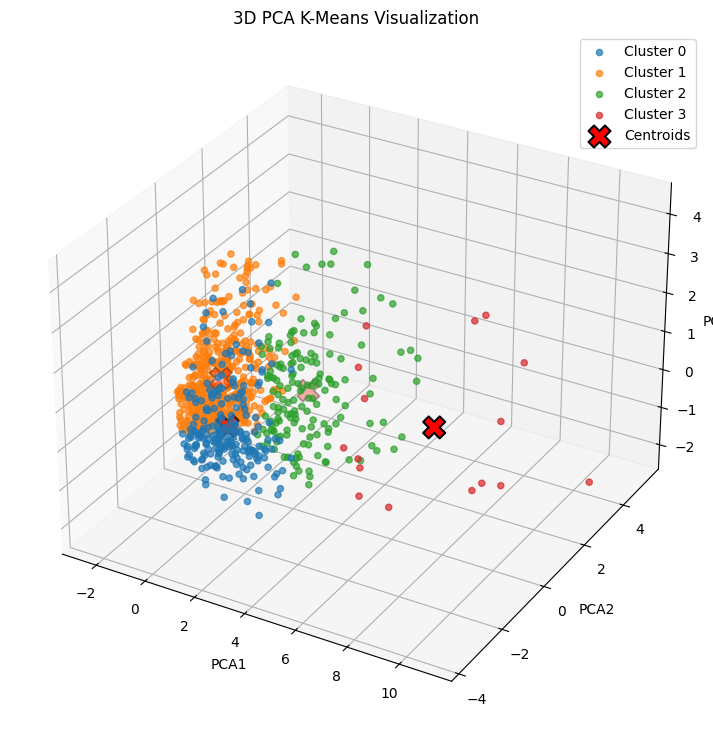

In [30]:
# PCA'yı 3 bileşene indir
pca = PCA(n_components=3) # PCA modelini oluşturur ve 3 bileşen kullanır.

# Veriyi 3 boyuta indir
pca_result = pca.fit_transform(X_scaled) # PCA modelini eğitir ve veriyi 3 bileşene dönüştürür.

# DataFrame'e ekle
df['PCA1'] = pca_result[:, 0] # PCA1 bileşenini df'e ekler.
df['PCA2'] = pca_result[:, 1] # PCA2 bileşenini df'e ekler.
df['PCA3'] = pca_result[:, 2] # PCA3 bileşenini df'e ekler.

# KMeans cluster merkezlerini de aynı PCA uzayına dönüştür
centers_pca_3d = pca.transform(kmeans_final.cluster_centers_) # KMeans modelinin öğrenilen küme merkezlerini PCA bileşenlerine dönüştürür.

# 3D figure
fig = plt.figure(figsize=(12, 9)) # 3D görselleştirme için bir grafik oluşturur.
ax = fig.add_subplot(111, projection='3d') # Grafiğe 3D eksen ekler ve ax değişkenine atar.

# Her cluster'ı ayrı çiz
for c in sorted(df['Cluster'].unique()): # Her bir küme için döngü oluşturur.
    subset = df[df['Cluster'] == c] # Her bir küme için df'den o kümeye ait veri noktalarını içeren bir alt küme oluşturur.

    ax.scatter(
        subset['PCA1'], # PCA1 bileşenini x eksenine yerleştirir.
        subset['PCA2'], # PCA2 bileşenini y eksenine yerleştirir.
        subset['PCA3'], # PCA3 bileşenini z eksenine yerleştirir.
        alpha=0.7, # Noktaların saydamlık seviyesini 0.7 olarak belirler.
        label=f'Cluster {c}' # Her bir kümenin etiketini belirler.
    ) # Her bir küme için PCA1, PCA2 ve PCA3 bileşenlerine göre noktaları 3D olarak görselleştirir.

# Merkezleri çiz
ax.scatter(
    centers_pca_3d[:, 0], # PCA1 bileşenindeki küme merkezlerini x eksenine yerleştirir.
    centers_pca_3d[:, 1], # PCA2 bileşenindeki küme merkezlerini y eksenine yerleştirir.
    centers_pca_3d[:, 2], # PCA3 bileşenindeki küme merkezlerini z eksenine yerleştirir.
    c='red', # Küme merkezlerinin rengini kırmızı olarak belirler.
    s=250, # Küme merkezlerinin boyutunu 250 olarak belirler.
    marker='X', # Küme merkezlerinin işaretleyicisini 'X' olarak belirler.
    edgecolors='black', # Küme merkezlerinin kenar renklerini siyah olarak belirler.
    linewidths=1.5, # Küme merkezlerinin kenar kalınlığını 1.5 olarak belirler.
    label='Centroids' # Küme merkezlerinin etiketini 'Centroids' olarak belirler.
)

ax.set_title('3D PCA K-Means Visualization') # Grafiğin başlığını belirler.
ax.set_xlabel('PCA1') # X ekseninin etiketini belirler.
ax.set_ylabel('PCA2') # Y ekseninin etiketini belirler.
ax.set_zlabel('PCA3') # Z ekseninin etiketini belirler.
ax.legend() # Legend'i gösterir.

plt.show()

In [32]:
print("Varyans Oranı:", pca.explained_variance_ratio_) # PCA'nın her bir bileşeninin toplam varyansın ne kadarını açıkladığını gösterir.
print("Toplam Varyans:", pca.explained_variance_ratio_.sum()) # PCA'nın seçilen bileşenlerinin toplam varyansın ne kadarını açıkladığını gösterir. Bu değer, PCA'nın veri setindeki varyansın ne kadarını koruduğunu gösterir.

Varyans Oranı: [0.44064321 0.21026295 0.15525396]
Toplam Varyans: 0.8061601298826442


In [33]:
def predict_new_customer(data_dict: dict) -> int:

    input_df = pd.DataFrame(
        data=[data_dict], # Yeni müşteri verisini içeren bir DataFrame oluşturur.
        columns=features # DataFrame'in sütun adlarını features listesine göre belirler.
    ) # Yeni müşteri verisini içeren bir DataFrame oluşturur ve sütun adlarını features listesine göre belirler.

    input_scaled = scaler.transform(input_df) # Yeni müşteri verisini eğitimde kullanılan scaler ile ölçeklendirir.

    cluster_label = int(kmeans_final.predict(input_scaled)[0]) # Yeni müşteri verisinin hangi kümeye ait olduğunu KMeans modelini kullanarak tahmin eder ve sonucu integer olarak döndürür.

    return cluster_label

In [34]:
features # features listesini yazdırır.

['Age',
 'Edu',
 'Years Employed',
 'Income',
 'Card Debt',
 'Other Debt',
 'DebtIncomeRatio']

In [39]:
df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio,Cluster,PCA1,PCA2,PCA3
0,41,2,6,19,0.124,1.073,6.3,1,-0.927909,-0.622244,0.330819
1,47,1,26,100,4.582,8.218,12.8,2,3.608097,-1.056633,-1.142474
2,33,2,10,57,6.111,5.802,20.9,2,1.868365,1.852803,-0.193044
3,29,2,4,19,0.681,0.516,6.3,1,-1.534416,0.092798,0.454891
4,47,1,31,253,9.308,8.908,7.2,3,6.665876,-2.265788,-0.190726


In [35]:
df[features].iloc[0].to_dict() # df'deki ilk satırın features sütunlarını içeren bir sözlük oluşturur ve yazdırır.

{'Age': 41.0,
 'Edu': 2.0,
 'Years Employed': 6.0,
 'Income': 19.0,
 'Card Debt': 0.124,
 'Other Debt': 1.073,
 'DebtIncomeRatio': 6.3}

In [38]:
new_customer = {
    'Age': 45,
    'Edu': 2,
    'Years Employed': 14,
    'Income': 150,
    'Card Debt': 4.2,
    'Other Debt': 3.4,
    'DebtIncomeRatio': 19.01
}

predicted_cluster = predict_new_customer(data_dict=new_customer) # Yeni müşteri verisi için hangi kümeye ait olduğunu tahmin eder.
predicted_cluster

c:\Users\90535\Desktop\SkilledHub\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


2

In [40]:
cluster_names = {
    0: "Low Income Customers",
    1: "Stable Customers",
    2: "High Income Customers",
    3: "Risk Customers"
}

predicted_cluster = predict_new_customer(data_dict=new_customer)
print("Predicted Cluster:", predicted_cluster)
print("Cluster Name:", cluster_names[predicted_cluster])
print(f"New customer belongs to {cluster_names[predicted_cluster]}.")

Predicted Cluster: 2
Cluster Name: High Income Customers
New customer belongs to High Income Customers.


c:\Users\90535\Desktop\SkilledHub\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
